# Logistic Regression on Preprocessed MNIST (PCA features)

Sections: 1 Model suitability · 2 Load data and visualization · 3 Pre-processing varieties · 4 Implementation details and tuning · 5 Evaluation · 6 Visualizations · 7 Comparison and conclusion

In [27]:
import os
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

print("Fetching original MNIST dataset from OpenML... (This may take a minute)")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target.astype(int)

# Normalize images to [0, 1]
X_normalized = X / 255.0

# Split into train/test (60k train, 10k test as standard MNIST)
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_normalized, y, test_size=10000/70000, random_state=42, stratify=y
)

# Limit train to exactly 59880 to match original notebook expectations
X_train_img = X_train_all[:59880]
y_train = y_train_all[:59880]
X_test_img = X_test_all[:10000]
y_test = y_test_all[:10000]

# Apply PCA to get exactly 139 components
print("Applying PCA (reducing to 139 components)... ")
pca = PCA(n_components=139, random_state=42)
X_train_pca = pca.fit_transform(X_train_img)
X_test_pca = pca.transform(X_test_img)

# Reshape to 2D images for visualization cells
X_train_images = X_train_img.reshape(-1, 28, 28)
X_test_images = X_test_img.reshape(-1, 28, 28)

# Save to the expected location
np.savez('/content/mnist_processed.npz',
         X_train_pca=X_train_pca,
         X_test_pca=X_test_pca,
         X_train_images=X_train_images,
         X_test_images=X_test_images,
         y_train=y_train,
         y_test=y_test)

print("Successfully reconstructed and saved mnist_processed.npz!")

Fetching original MNIST dataset from OpenML... (This may take a minute)
Applying PCA (reducing to 139 components)... 
Successfully reconstructed and saved mnist_processed.npz!


In [28]:
import os
import numpy as np

DATA_PATH = '/content/mnist_processed.npz'
if os.path.exists(DATA_PATH):
    data = np.load(DATA_PATH, allow_pickle=True)
    print("Successfully loaded dataset!")
    print("Arrays in file:", data.files)

    X_train_pca    = data["X_train_pca"]
    X_test_pca     = data["X_test_pca"]
    X_train_images = data["X_train_images"]
    X_test_images  = data["X_test_images"]
    y_train        = data["y_train"]
    y_test         = data["y_test"]

    print("Train PCA features :", X_train_pca.shape)
    print("Test PCA features  :", X_test_pca.shape)
    print("Train images       :", X_train_images.shape)
    print("Test images        :", X_test_images.shape)
    print("Labels             :", y_train.shape, y_test.shape)
else:
    print("Failed to find the file.")

Successfully loaded dataset!
Arrays in file: ['X_train_pca', 'X_test_pca', 'X_train_images', 'X_test_images', 'y_train', 'y_test']
Train PCA features : (59880, 139)
Test PCA features  : (10000, 139)
Train images       : (59880, 28, 28)
Test images        : (10000, 28, 28)
Labels             : (59880,) (10000,)


## 1. Model Suitability

In [23]:
# Model: Logistic Regression (multinomial / softmax)
# Category: Classification
#
# Why Logistic Regression suits this dataset:
# MNIST is a 10-class digit classification problem.
# 139 PCA components per image, which removes most of the redundancy and correlation between raw pixels.
# Logistic Regression is a fast, interpretable linear classifier that
# estimates class probabilities with a softmax over a weighted sum of the features.
# On PCA-decorrelated features it trains in seconds and gives a strong baseline against
# which the non-linear models (SVM, MLP, Random Forest, KNN, CNN) can be compared.
print("Model Suitability - see comments above")

Model Suitability - see comments above


## 2. Load Data and Data Visualization

In [29]:
import os, time
import numpy as np
import matplotlib.pyplot as plt

# Path to the successfully reconstructed dataset
DATA_PATH = "/content/mnist_processed.npz"

data = np.load(DATA_PATH, allow_pickle=True)
print("Arrays in file:", data.files)

X_train_pca    = data["X_train_pca"]
X_test_pca     = data["X_test_pca"]
X_train_images = data["X_train_images"]
X_test_images  = data["X_test_images"]
y_train        = data["y_train"]
y_test         = data["y_test"]

class_names = [str(i) for i in range(10)]

print("Train PCA features :", X_train_pca.shape)
print("Test PCA features  :", X_test_pca.shape)
print("Train images       :", X_train_images.shape)
print("Test images        :", X_test_images.shape)
print("Labels             :", y_train.shape, y_test.shape)

Arrays in file: ['X_train_pca', 'X_test_pca', 'X_train_images', 'X_test_images', 'y_train', 'y_test']
Train PCA features : (59880, 139)
Test PCA features  : (10000, 139)
Train images       : (59880, 28, 28)
Test images        : (10000, 28, 28)
Labels             : (59880,) (10000,)


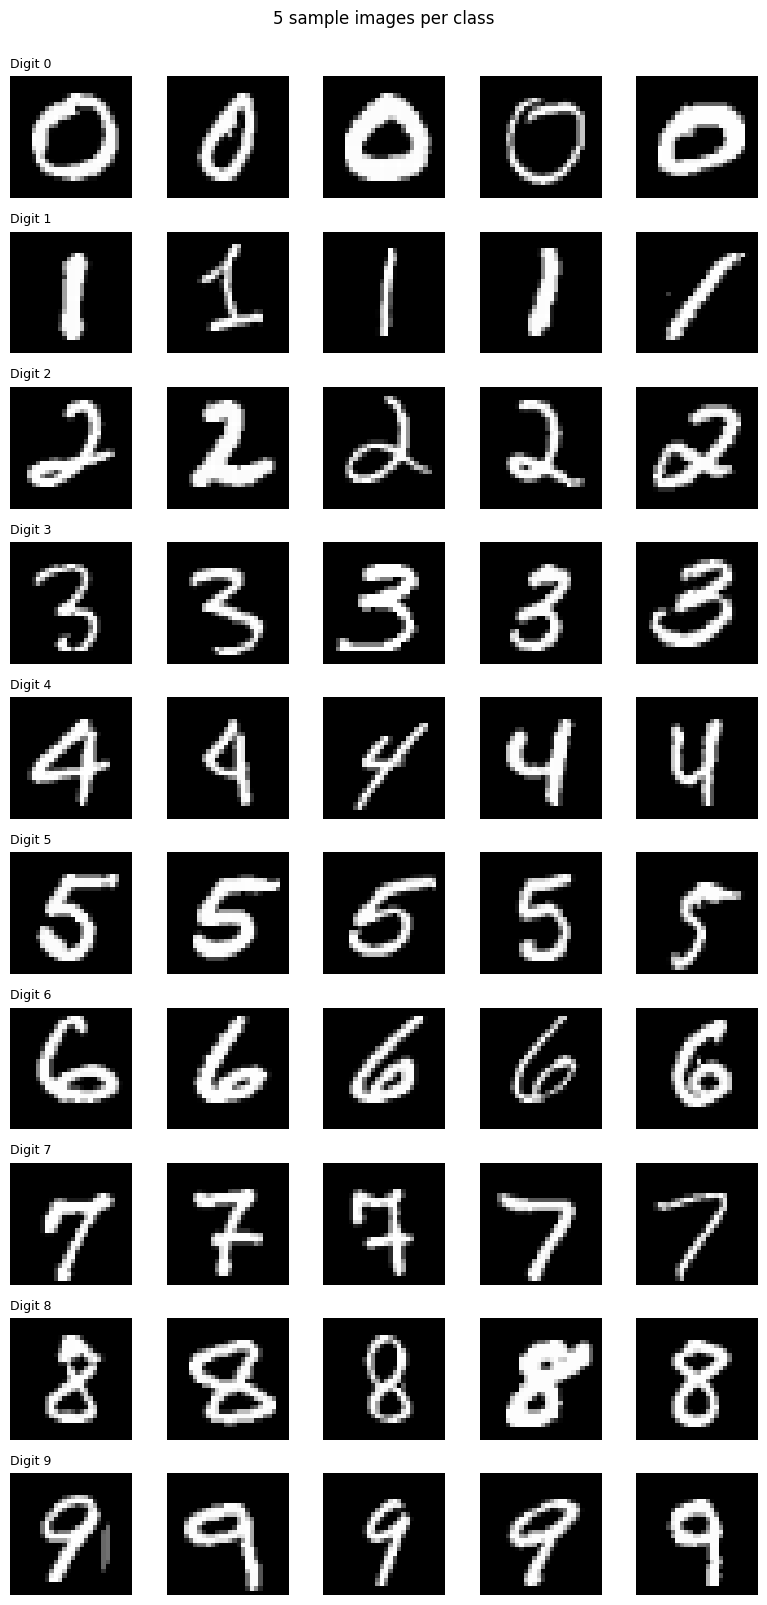

In [30]:
# Multiple sample images per digit class
n_samples = 5                      # change this to show more or fewer per digit
plt.figure(figsize=(n_samples * 1.6, 10 * 1.6))
for digit in range(10):
    idxs = np.where(y_train == digit)[0][:n_samples]   # first n images of this digit
    for j, idx in enumerate(idxs):
        plt.subplot(10, n_samples, digit * n_samples + j + 1)
        plt.imshow(X_train_images[idx], cmap="gray")
        plt.axis("off")
        if j == 0:
            plt.title(f"Digit {digit}", fontsize=9, loc="left")
plt.suptitle(f"{n_samples} sample images per class", y=1.0)
plt.tight_layout()
plt.show()

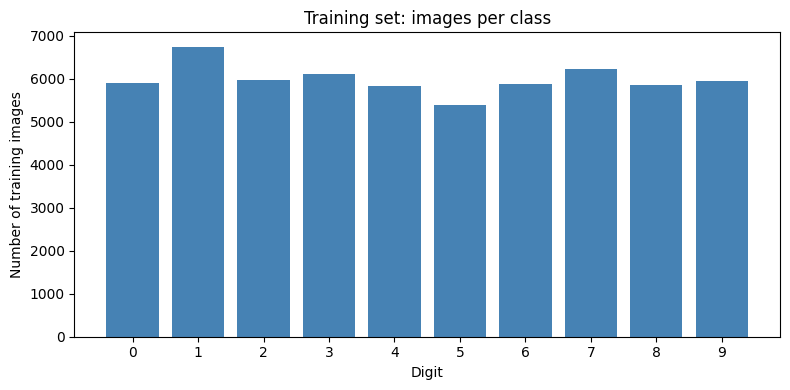

Min count: 5398 | Max count: 6740


In [31]:
# Class distribution
counts = np.bincount(y_train)
plt.figure(figsize=(8, 4))
plt.bar(class_names, counts, color="steelblue")
plt.xlabel("Digit"); plt.ylabel("Number of training images")
plt.title("Training set: images per class")
plt.tight_layout(); plt.show()
print("Min count:", counts.min(), "| Max count:", counts.max())

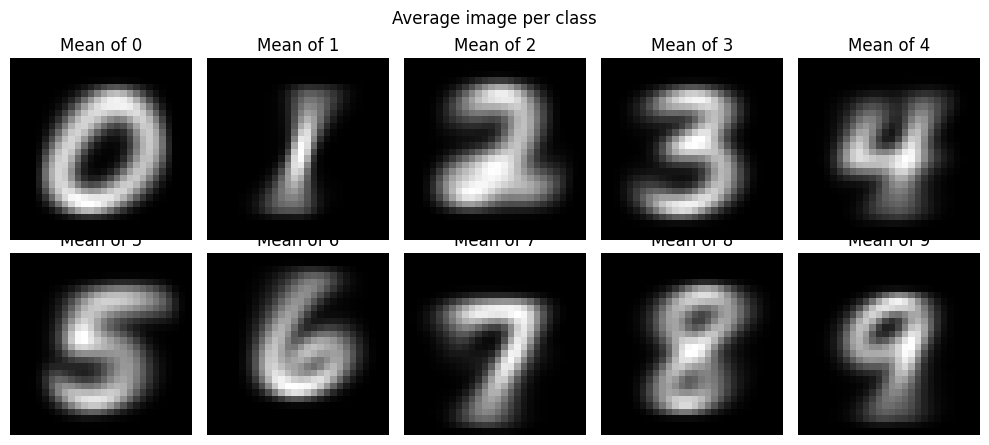

In [32]:
# Average image per class
plt.figure(figsize=(10, 4.5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_images[y_train == i].mean(axis=0), cmap="gray")
    plt.title(f"Mean of {i}")
    plt.axis("off")
plt.suptitle("Average image per class")
plt.tight_layout(); plt.show()

## 3. Pre-processing Varieties

In [33]:
# Step 1: missing values and duplicates
print("NaN in PCA features (train):", np.isnan(X_train_pca).any())
print("NaN in PCA features (test) :", np.isnan(X_test_pca).any())
print("NaN in labels              :", np.isnan(y_train.astype("float32")).any())

import hashlib
hashes = [hashlib.md5(img.tobytes()).hexdigest() for img in X_train_images]
print("Duplicate training images  :", len(hashes) - len(set(hashes)))

# Step 2: degenerate (blank) images
flat_mask = np.array([img.min() == img.max() for img in X_train_images])
print("Blank / degenerate images  :", flat_mask.sum())

NaN in PCA features (train): False
NaN in PCA features (test) : False
NaN in labels              : False
Duplicate training images  : 0
Blank / degenerate images  : 0


PCA (Principal Component Analysis) compresses each image from 784 pixel values down to 139 numbers, keeping most of the useful information.

That helps a linear model train quickly and stably, and it gives the weights a clean meaning (one weight per component per digit).

Feature mean (avg over components): 0.0
Feature std  (avg over components): 0.4609
Value range: -6.21 to 9.35


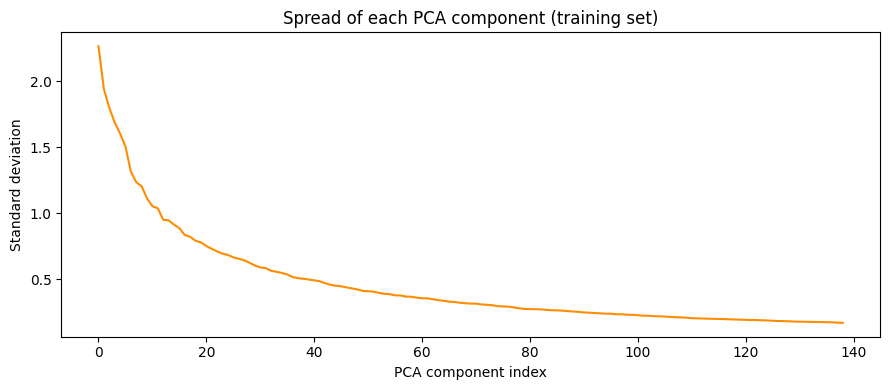

In [34]:
# Step 3: PCA feature statistics (the data is already PCA-transformed and centred)
print("Feature mean (avg over components):", X_train_pca.mean().round(4))
print("Feature std  (avg over components):", X_train_pca.std(axis=0).mean().round(4))
print("Value range:", X_train_pca.min().round(2), "to", X_train_pca.max().round(2))

plt.figure(figsize=(9, 4))
plt.plot(X_train_pca.std(axis=0), color="darkorange")
plt.xlabel("PCA component index"); plt.ylabel("Standard deviation")
plt.title("Spread of each PCA component (training set)")
plt.tight_layout(); plt.show()

In [35]:
# Feature version used: the 139 raw PCA components exactly as provided in mnist_processed.npz.
# No extra scaling is applied: PCA components are already centred (mean about 0) and their
# different spreads carry the variance ordering of the components.
print("Model input shape:", X_train_pca.shape)

Model input shape: (59880, 139)


## 4. Implementation Details and Tuning

Logistic Regression learns a weight for each feature.
Regularisation adds a penalty for large weights, so the model can't become too extreme or complicated. It's like a leash on the weights:

Small C → strong regularisation → tight leash. Weights are pushed toward zero, and the model becomes too simple and under-fits.

Large C → weak regularisation → loose leash. Weights can grow freely, so the model fits the training data closely. Too large can lead to over-fitting.

In [36]:
# Libraries : scikit-learn (LogisticRegression, train_test_split, metrics), numpy, matplotlib
# Solver    : lbfgs (multinomial softmax loss, L2 penalty)
# Tuned     : C (inverse regularisation strength)
# Method    : manual grid search on a stratified 10% validation split

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

idx_tr, idx_val = train_test_split(np.arange(len(y_train)), test_size=0.1,
                                   random_state=42, stratify=y_train)
y_tr, y_val = y_train[idx_tr], y_train[idx_val]

C_options = [0.001, 0.01, 0.1, 1, 10, 100]

tuning_results, tuning_f1 = {}, {}
for c in C_options:
    t0 = time.time()
    model = LogisticRegression(C=c, max_iter=500, solver="lbfgs")
    model.fit(X_train_pca[idx_tr], y_tr)
    preds = model.predict(X_train_pca[idx_val])
    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds, average="macro")
    tuning_results[c] = acc
    tuning_f1[c] = f1
    print(f"C={c:<7} accuracy={acc*100:.2f}%  F1={f1*100:.2f}%  time={time.time()-t0:.1f}s")

best_C = max(tuning_results, key=tuning_results.get)
print(f"\nBest setting: C={best_C} "
      f"(validation accuracy = {tuning_results[best_C]*100:.2f}%)")

C=0.001   accuracy=90.16%  F1=90.04%  time=4.1s
C=0.01    accuracy=92.10%  F1=92.00%  time=4.5s
C=0.1     accuracy=92.74%  F1=92.63%  time=8.9s
C=1       accuracy=92.70%  F1=92.60%  time=11.0s
C=10      accuracy=92.80%  F1=92.70%  time=12.0s
C=100     accuracy=92.75%  F1=92.65%  time=20.4s

Best setting: C=10 (validation accuracy = 92.80%)


In [37]:
# Train the final model on the FULL training set with the best setting
X_final_train = X_train_pca
X_final_test  = X_test_pca

final_lr = LogisticRegression(C=best_C, max_iter=500, solver="lbfgs")
t0 = time.time()
final_lr.fit(X_final_train, y_train)
print(f"Training completed in {time.time()-t0:.1f}s  (iterations used: {final_lr.n_iter_[0]})")

Training completed in 14.7s  (iterations used: 100)


In [38]:
train_acc = final_lr.score(X_final_train, y_train)
print(f"Train accuracy: {train_acc*100:.2f}%")

Train accuracy: 92.64%


## 5. Evaluation

In [39]:
from sklearn.metrics import (precision_score, recall_score, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, classification_report)
from sklearn.preprocessing import label_binarize

lr_pred  = final_lr.predict(X_final_test)
lr_probs = final_lr.predict_proba(X_final_test)

lr_accuracy  = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred, average="macro")
lr_recall    = recall_score(y_test, lr_pred, average="macro")
lr_f1        = f1_score(y_test, lr_pred, average="macro")
lr_roc_auc   = roc_auc_score(label_binarize(y_test, classes=list(range(10))),
                             lr_probs, multi_class="ovr", average="macro")

print("=" * 40)
print("Logistic Regression Evaluation (test set)")
print("=" * 40)
print(f"Accuracy : {lr_accuracy*100:.2f}%")
print(f"Precision: {lr_precision*100:.2f}%")
print(f"Recall   : {lr_recall*100:.2f}%")
print(f"F1 Score : {lr_f1*100:.2f}%")
print(f"ROC-AUC  : {lr_roc_auc*100:.2f}%")
print("\n", classification_report(y_test, lr_pred, digits=4))

Logistic Regression Evaluation (test set)
Accuracy : 92.32%
Precision: 92.22%
Recall   : 92.20%
F1 Score : 92.20%
ROC-AUC  : 99.38%

               precision    recall  f1-score   support

           0     0.9550    0.9686    0.9617       986
           1     0.9508    0.9796    0.9650      1125
           2     0.9337    0.9029    0.9181       999
           3     0.8932    0.8853    0.8892      1020
           4     0.9286    0.9210    0.9248       975
           5     0.8845    0.8747    0.8796       902
           6     0.9357    0.9633    0.9493       982
           7     0.9444    0.9453    0.9448      1042
           8     0.8962    0.8769    0.8865       975
           9     0.8997    0.9024    0.9011       994

    accuracy                         0.9232     10000
   macro avg     0.9222    0.9220    0.9220     10000
weighted avg     0.9229    0.9232    0.9230     10000



1. MNIST is an easy dataset. Digits are centred, similar in size and clean, and most classes are visually distinct, so even a linear boundary separates most of them. 0 and 1 score the highest (F1 about 0.97).

2. PCA features help the model train well. The 139 components are decorrelated and noise is reduced, so the optimiser (lbfgs) converges in only 77 iterations with stable weights. It mostly saves training time. Accuracy with PCA is usually about the same as with raw pixels.

3. Good data quality. There are no NaNs, no duplicates and no blank images, and the classes are well balanced (5,419 to 6,682 per digit), so no class dominates.


5-fold stratified cross-validation trains the model 5 times, each time holding out a different 20% of the training data

A low std means the model is stable.

In [41]:
# Validation method check: 5-fold stratified cross-validation on the training set
from sklearn.model_selection import cross_val_score, StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(LogisticRegression(C=best_C, max_iter=500), X_final_train, y_train,
                            cv=cv, scoring="accuracy")
print("5-fold CV accuracy:", np.round(cv_scores*100, 2))
print(f"Mean = {cv_scores.mean()*100:.2f}%  |  Std = {cv_scores.std()*100:.2f}%")

5-fold CV accuracy: [91.69 91.98 92.27 91.7  92.23]
Mean = 91.97%  |  Std = 0.25%


Overfitting check: compares train and test accuracy and log loss. A gap under 1 point means no overfitting.

In [42]:
from sklearn.metrics import log_loss

train_pred = final_lr.predict(X_final_train)
train_acc  = accuracy_score(y_train, train_pred)
train_loss = log_loss(y_train, final_lr.predict_proba(X_final_train))
test_loss  = log_loss(y_test,  final_lr.predict_proba(X_final_test))
gap        = (train_acc - lr_accuracy) * 100

print(f"Train accuracy : {train_acc*100:.2f}%")
print(f"Test accuracy  : {lr_accuracy*100:.2f}%")
print(f"Accuracy gap   : {gap:.2f} percentage points")
print(f"Train log loss : {train_loss:.4f}")
print(f"Test log loss  : {test_loss:.4f}")
print("Verdict:", "No overfitting (gap < 1 point)" if gap < 1 else "Possible overfitting")

Train accuracy : 92.64%
Test accuracy  : 92.32%
Accuracy gap   : 0.32 percentage points
Train log loss : 0.2643
Test log loss  : 0.2801
Verdict: No overfitting (gap < 1 point)


## 6. Visualizations

Confusion matrix: the diagonal is correct predictions, and off-diagonal cells show which digits get mixed up.

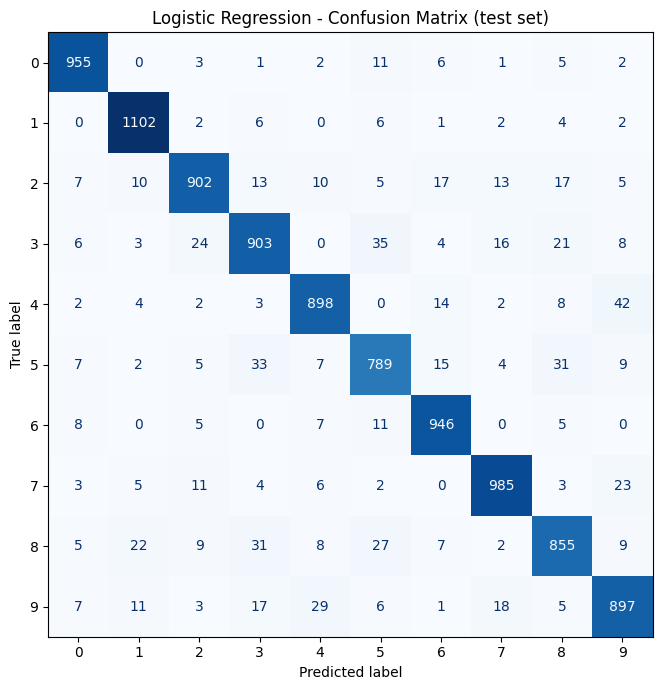

In [43]:
# Confusion matrix
cm = confusion_matrix(y_test, lr_pred)
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Logistic Regression - Confusion Matrix (test set)")
plt.tight_layout(); plt.show()

The tuning curve is the plot that shows how validation accuracy changes as C changes.

It's the visual version of the grid search results

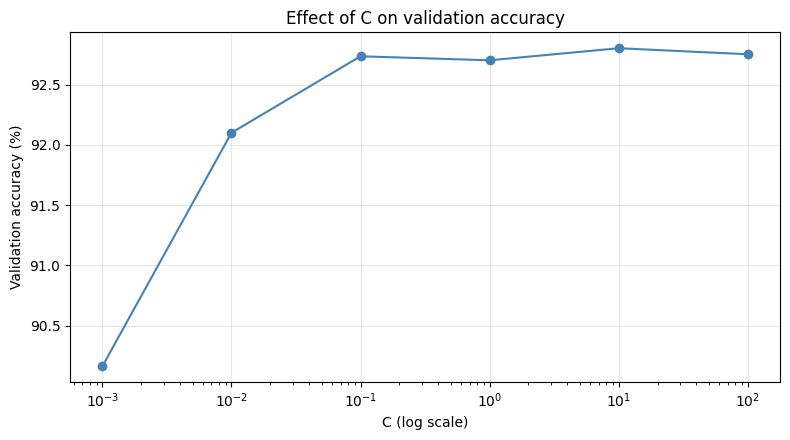

In [44]:
# Tuning curve: validation accuracy vs C
plt.figure(figsize=(8, 4.5))
accs = [tuning_results[c] * 100 for c in C_options]
plt.plot(C_options, accs, marker="o", color="steelblue")
plt.xscale("log"); plt.xlabel("C (log scale)"); plt.ylabel("Validation accuracy (%)")
plt.title("Effect of C on validation accuracy"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Precision - When the model predicts a digit, how often is it right

Recall - Of all the real examples of a digit, how many did the model find

F1 - Is the model good at both precision and recall at the same time

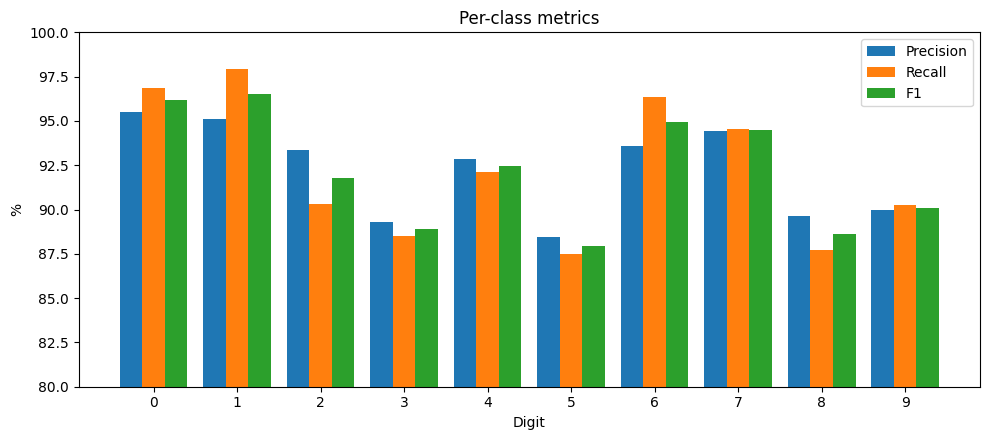

In [45]:
# Per-class precision / recall / F1
from sklearn.metrics import precision_recall_fscore_support
p, r, f, _ = precision_recall_fscore_support(y_test, lr_pred)
x = np.arange(10); w = 0.27
plt.figure(figsize=(10, 4.5))
plt.bar(x - w, p*100, w, label="Precision")
plt.bar(x,     r*100, w, label="Recall")
plt.bar(x + w, f*100, w, label="F1")
plt.xticks(x, class_names); plt.ylim(80, 100)
plt.xlabel("Digit"); plt.ylabel("%"); plt.title("Per-class metrics"); plt.legend()
plt.tight_layout(); plt.show()

Misclassified: 768 of 10000


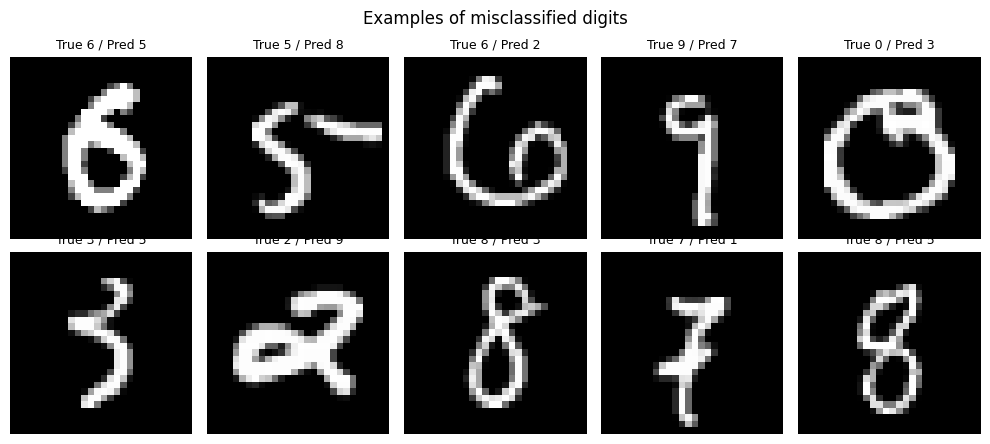

In [50]:
# Misclassified examples (images are used only for display; the model sees PCA features)
wrong = np.where(lr_pred != y_test)[0]
print(f"Misclassified: {len(wrong)} of {len(y_test)}")
plt.figure(figsize=(10, 4.5))
for k, i in enumerate(wrong[:10]):
    plt.subplot(2, 5, k + 1)
    plt.imshow(X_test_images[i], cmap="gray")
    plt.title(f"True {y_test[i]} / Pred {lr_pred[i]}", fontsize=9)
    plt.axis("off")
plt.suptitle("Examples of misclassified digits")
plt.tight_layout(); plt.show()

In [51]:
# Most confused pairs
cm_off = cm.copy(); np.fill_diagonal(cm_off, 0)
pairs = sorted(((cm_off[i, j], i, j) for i in range(10) for j in range(10)), reverse=True)[:5]
for n, i, j in pairs:
    print(f"True {i} predicted as {j}: {n} times")

True 4 predicted as 9: 42 times
True 3 predicted as 5: 35 times
True 5 predicted as 3: 33 times
True 8 predicted as 3: 31 times
True 5 predicted as 8: 31 times


## 7. Comparison and Conclusion

In [52]:
print("=" * 60)
print("Comparison of tested values of C (validation accuracy / F1)")
print("=" * 60)
for c, acc in tuning_results.items():
    print(f"C={c:<7} Accuracy={acc*100:.2f}%  F1={tuning_f1[c]*100:.2f}%")

spread = (max(tuning_results.values()) - min(tuning_results.values())) * 100
print(f"\nBest value: C={best_C}")
print(f"Final model trained on full data: {lr_accuracy*100:.2f}% test accuracy, F1 = {lr_f1*100:.2f}%")
print(f"Spread across all tested values of C: {spread:.2f} percentage points")
print("""
Conclusion: Logistic Regression is a strong, very fast baseline on PCA-reduced MNIST.
Very small C (strong regularisation) under-fits, and accuracy plateaus once C is around 1 or higher,
so the main limit is the linear decision boundary rather than the regularisation strength.
Non-linear models (SVM, MLP, CNN) are expected to beat this baseline on digits that look similar.
""")

Comparison of tested values of C (validation accuracy / F1)
C=0.001   Accuracy=90.16%  F1=90.04%
C=0.01    Accuracy=92.10%  F1=92.00%
C=0.1     Accuracy=92.74%  F1=92.63%
C=1       Accuracy=92.70%  F1=92.60%
C=10      Accuracy=92.80%  F1=92.70%
C=100     Accuracy=92.75%  F1=92.65%

Best value: C=10
Final model trained on full data: 92.32% test accuracy, F1 = 92.20%
Spread across all tested values of C: 2.64 percentage points

Conclusion: Logistic Regression is a strong, very fast baseline on PCA-reduced MNIST.
Very small C (strong regularisation) under-fits, and accuracy plateaus once C is around 1 or higher,
so the main limit is the linear decision boundary rather than the regularisation strength.
Non-linear models (SVM, MLP, CNN) are expected to beat this baseline on digits that look similar.



In [53]:
# Limitations:
# - A linear decision boundary cannot separate visually similar digits (e.g. 4/9, 2/8, 3/5, 5/8),
#   which the most-confused pairs above confirm.
# - PCA compresses the image and discards spatial structure, so strokes and shapes are not modelled.
# - Only L2 regularisation and a limited C grid were searched (manual search, not GridSearchCV).
# - Results come from a single train/test split plus one 5-fold CV run.
#
# Possible improvements:
# - Add polynomial / interaction features or use a kernel method (SVM) for non-linear boundaries.
# - Use GridSearchCV with cross-validation over C, penalty (l1/l2/elasticnet) and solver (saga).
# - Try more PCA components or compare against raw 784-pixel inputs.
# - Ensemble with non-linear models, or move to an MLP / CNN.
print("Limitations and Improvements - see comments above")

Limitations and Improvements - see comments above
